# Notebook 4: Model Evaluation

## Stock Price Forecasting Application

---

**Objective:** Perform comprehensive evaluation and comparison of all trained models, select the best performer, and document findings and recommendations.

**Models Evaluated:**
- Linear Regression (Pipeline: StandardScaler → LinearRegression)
- Polynomial Regression (Pipeline: StandardScaler → PolynomialFeatures → LinearRegression)
- Random Forest (GridSearchCV-tuned)
- XGBoost (GridSearchCV-tuned)
- LSTM Neural Network

**Evaluation Approach:**
- Compare models using multiple regression metrics (RMSE, MAE, R²)
- Visualize predictions vs. actual prices
- Analyze residuals and prediction errors
- Assess feature importance across models
- Select the optimal model with justification
- Discuss deployment considerations

## 4.1 Import Libraries and Load Results

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# Load predictions and results from modeling notebook
data_dir = os.path.join('..', 'data')
models_dir = os.path.join('..', 'models')

predictions = pd.read_csv(os.path.join(data_dir, 'all_predictions.csv'), index_col='Date', parse_dates=True)
model_results = pd.read_csv(os.path.join(data_dir, 'model_results.csv'), index_col='Model')

# Detect which polynomial degree column is present
poly_col = [c for c in predictions.columns if c.startswith('Polynomial_deg')]
poly_col_name = poly_col[0] if poly_col else None
poly_degree = int(poly_col_name.replace('Polynomial_deg', '')) if poly_col_name else None

print(f'Predictions shape: {predictions.shape}')
print(f'Date range: {predictions.index.min().date()} to {predictions.index.max().date()}')
print(f'\nModels evaluated: {list(predictions.columns[1:])}')
if poly_degree:
    print(f'Polynomial degree used: {poly_degree}')
predictions.head()

Predictions shape: (494, 5)
Date range: 2023-01-12 to 2024-12-30

Models evaluated: ['Linear_Regression', 'Random_Forest', 'XGBoost', 'LSTM']


,Actual,Linear_Regression,Random_Forest,XGBoost,LSTM
Date,,,,,
2023-01-12,132.6331,130.7170,130.5895,130.6440,NaN
2023-01-13,133.7944,132.4159,131.3277,132.4808,NaN
2023-01-17,133.0760,133.8471,134.2953,135.5156,NaN
2023-01-18,133.1351,133.3637,134.7785,135.5026,NaN
2023-01-19,135.6940,133.4859,132.6436,133.8811,NaN


## 4.2 Evaluation Metrics Overview

We evaluate each model using three complementary regression metrics:

| Metric | Description | Ideal Value |
|--------|-------------|-------------|
| **RMSE** (Root Mean Square Error) | Penalizes large errors more heavily; same units as target | Lower is better |
| **MAE** (Mean Absolute Error) | Average absolute prediction error; robust to outliers | Lower is better |
| **R² Score** (Coefficient of Determination) | Proportion of variance explained by the model | Closer to 1.0 is better |

Using multiple metrics provides a more complete picture — RMSE highlights if a model makes occasional large errors, while MAE gives the typical error magnitude.

In [3]:
# Recalculate metrics for all models from predictions
model_names = ['Linear_Regression']
display_names = ['Linear Regression']

# Dynamically add polynomial regression if present
if poly_col_name:
    model_names.append(poly_col_name)
    display_names.append(f'Polynomial Regression (deg={poly_degree})')

model_names += ['Random_Forest', 'XGBoost', 'LSTM']
display_names += ['Random Forest', 'XGBoost', 'LSTM']

actual = predictions['Actual']

eval_results = []
for model_col, display_name in zip(model_names, display_names):
    if model_col in predictions.columns:
        # Drop NaN for LSTM (which has fewer predictions)
        mask = predictions[model_col].notna()
        y_true = actual[mask]
        y_pred = predictions[model_col][mask]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        eval_results.append({
            'Model': display_name,
            'RMSE': rmse,
            'MAE': mae,
            'R² Score': r2,
            'Samples': mask.sum()
        })

eval_df = pd.DataFrame(eval_results).set_index('Model')

print('='*65)
print('MODEL EVALUATION — Test Set Performance')
print('='*65)
display(eval_df.style
        .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R² Score': '{:.6f}', 'Samples': '{:.0f}'})
        .highlight_min(subset=['RMSE', 'MAE'], color='#90EE90')
        .highlight_max(subset=['R² Score'], color='#90EE90'))

MODEL EVALUATION — Test Set Performance


,RMSE,MAE,R² Score,Samples
Model,,,,
Linear Regression,2.5966,1.9166,0.990876,494
Random Forest,30.1611,20.4686,-0.231042,494
XGBoost,33.9103,24.3995,-0.556122,494
LSTM,36.6768,28.4500,-1.076908,464


## 4.3 Visual Model Comparison

### 4.3.1 Metric Bar Charts

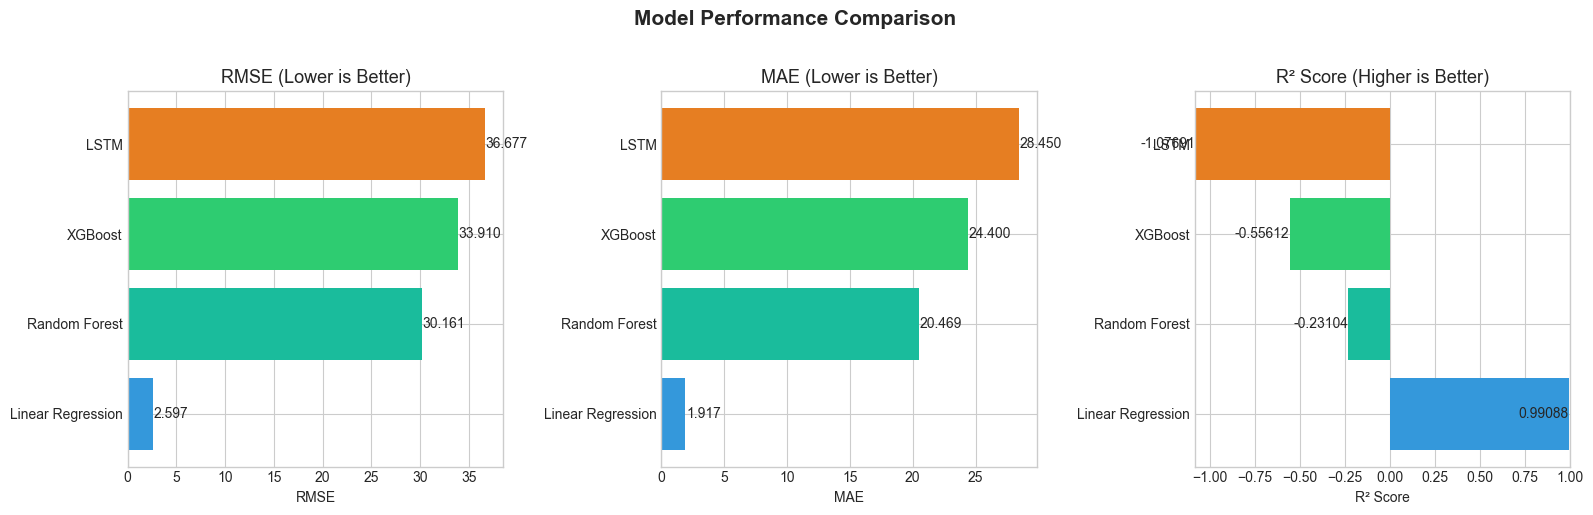

In [4]:
# Bar chart comparison of metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#1abc9c', '#2ecc71', '#e67e22', '#9b59b6'][:len(eval_df)]

# RMSE
axes[0].barh(eval_df.index, eval_df['RMSE'], color=colors)
axes[0].set_title('RMSE (Lower is Better)', fontsize=13)
axes[0].set_xlabel('RMSE')
for i, v in enumerate(eval_df['RMSE']):
    axes[0].text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=10)

# MAE
axes[1].barh(eval_df.index, eval_df['MAE'], color=colors)
axes[1].set_title('MAE (Lower is Better)', fontsize=13)
axes[1].set_xlabel('MAE')
for i, v in enumerate(eval_df['MAE']):
    axes[1].text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=10)

# R² Score
axes[2].barh(eval_df.index, eval_df['R² Score'], color=colors)
axes[2].set_title('R² Score (Higher is Better)', fontsize=13)
axes[2].set_xlabel('R² Score')
axes[2].set_xlim([eval_df['R² Score'].min() - 0.005, 1.001])
for i, v in enumerate(eval_df['R² Score']):
    axes[2].text(v - 0.003, i, f'{v:.5f}', va='center', fontsize=10, ha='right')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3.2 Predictions vs. Actual Prices — All Models

In [5]:
# Interactive plot: Actual vs. all model predictions
fig = go.Figure()

# Actual prices
fig.add_trace(go.Scatter(
    x=predictions.index, y=predictions['Actual'],
    mode='lines', name='Actual',
    line=dict(color='black', width=2)
))

# Model predictions
colors_pred = {'Linear_Regression': '#3498db', 'Random_Forest': '#2ecc71',
               'XGBoost': '#e67e22', 'LSTM': '#9b59b6'}
if poly_col_name:
    colors_pred[poly_col_name] = '#1abc9c'

for model_col, display_name in zip(model_names, display_names):
    if model_col in predictions.columns:
        fig.add_trace(go.Scatter(
            x=predictions.index, y=predictions[model_col],
            mode='lines', name=display_name,
            line=dict(color=colors_pred.get(model_col, '#95a5a6'), width=1.5, dash='dot')
        ))

fig.update_layout(
    title='AAPL — Actual vs. Predicted Closing Prices (Test Set)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_white',
    height=550,
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01)
)
fig.show()

### 4.3.3 Zoomed View — Last 60 Trading Days

In [6]:
# Zoomed view of last 60 days
recent = predictions.tail(60)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=recent.index, y=recent['Actual'],
    mode='lines+markers', name='Actual',
    line=dict(color='black', width=2), marker=dict(size=3)
))

for model_col, display_name in zip(model_names, display_names):
    if model_col in recent.columns:
        fig.add_trace(go.Scatter(
            x=recent.index, y=recent[model_col],
            mode='lines+markers', name=display_name,
            line=dict(color=colors_pred.get(model_col, '#95a5a6'), width=1.5),
            marker=dict(size=3)
        ))

fig.update_layout(
    title='AAPL — Predictions vs Actual (Last 60 Trading Days)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_white',
    height=450
)
fig.show()

## 4.4 Residual Analysis

Residuals (prediction errors = actual - predicted) reveal systematic biases in model predictions. Ideally, residuals should be centered around zero with no discernible pattern.

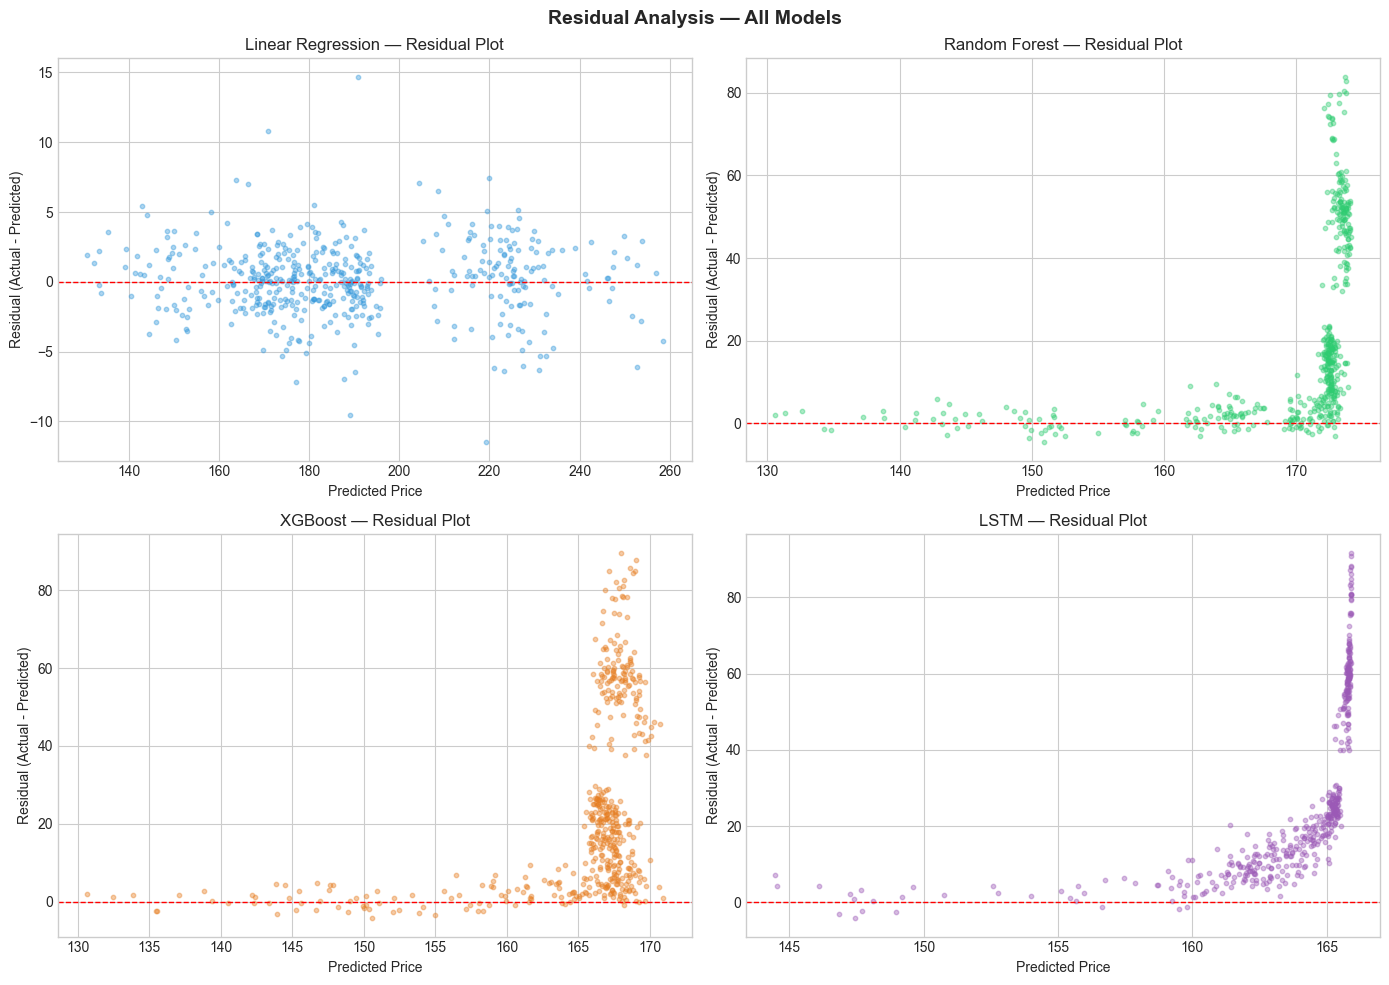

In [ ]:
# Compute residuals for all models
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for idx, (model_col, display_name) in enumerate(zip(model_names, display_names)):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        residuals = predictions.loc[mask, 'Actual'] - predictions.loc[mask, model_col]
        
        axes[idx].scatter(predictions.loc[mask, model_col], residuals,
                         alpha=0.4, s=10, color=colors[idx])
        axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1)
        axes[idx].set_title(f'{display_name} — Residual Plot', fontsize=12)
        axes[idx].set_xlabel('Predicted Price')
        axes[idx].set_ylabel('Residual (Actual - Predicted)')

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Residual Analysis — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

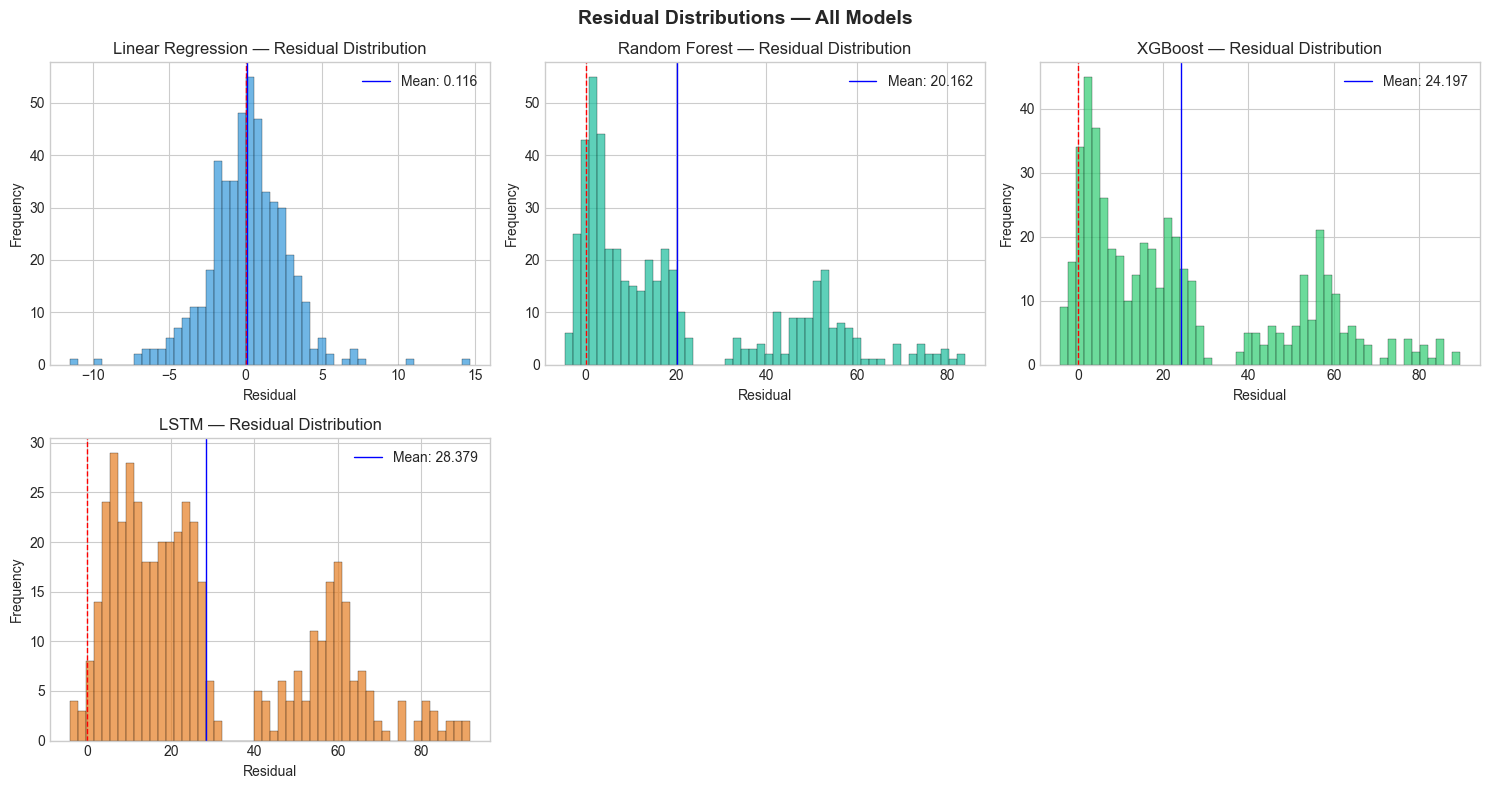

In [8]:
# Residual distribution (histogram)
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for idx, (model_col, display_name) in enumerate(zip(model_names, display_names)):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        residuals = predictions.loc[mask, 'Actual'] - predictions.loc[mask, model_col]
        
        axes[idx].hist(residuals, bins=50, alpha=0.7, color=colors[idx], edgecolor='black', linewidth=0.3)
        axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1)
        axes[idx].axvline(x=residuals.mean(), color='blue', linestyle='-', linewidth=1,
                         label=f'Mean: {residuals.mean():.3f}')
        axes[idx].set_title(f'{display_name} — Residual Distribution', fontsize=12)
        axes[idx].set_xlabel('Residual')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Residual Distributions — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.5 Prediction Error Over Time

In [ ]:
# Absolute error over time
fig = go.Figure()

for model_col, display_name in zip(model_names, display_names):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        abs_error = (predictions.loc[mask, 'Actual'] - predictions.loc[mask, model_col]).abs()
        # Rolling 20-day average for clarity
        rolling_error = abs_error.rolling(window=20).mean()
        fig.add_trace(go.Scatter(
            x=rolling_error.index, y=rolling_error,
            mode='lines', name=display_name,
            line=dict(color=colors_pred.get(model_col, '#95a5a6'))
        ))

fig.update_layout(
    title='20-Day Rolling Average Absolute Error',
    xaxis_title='Date',
    yaxis_title='Absolute Error (USD)',
    template='plotly_white',
    height=400
)
fig.show()

## 4.6 Scatter Plot: Predicted vs. Actual

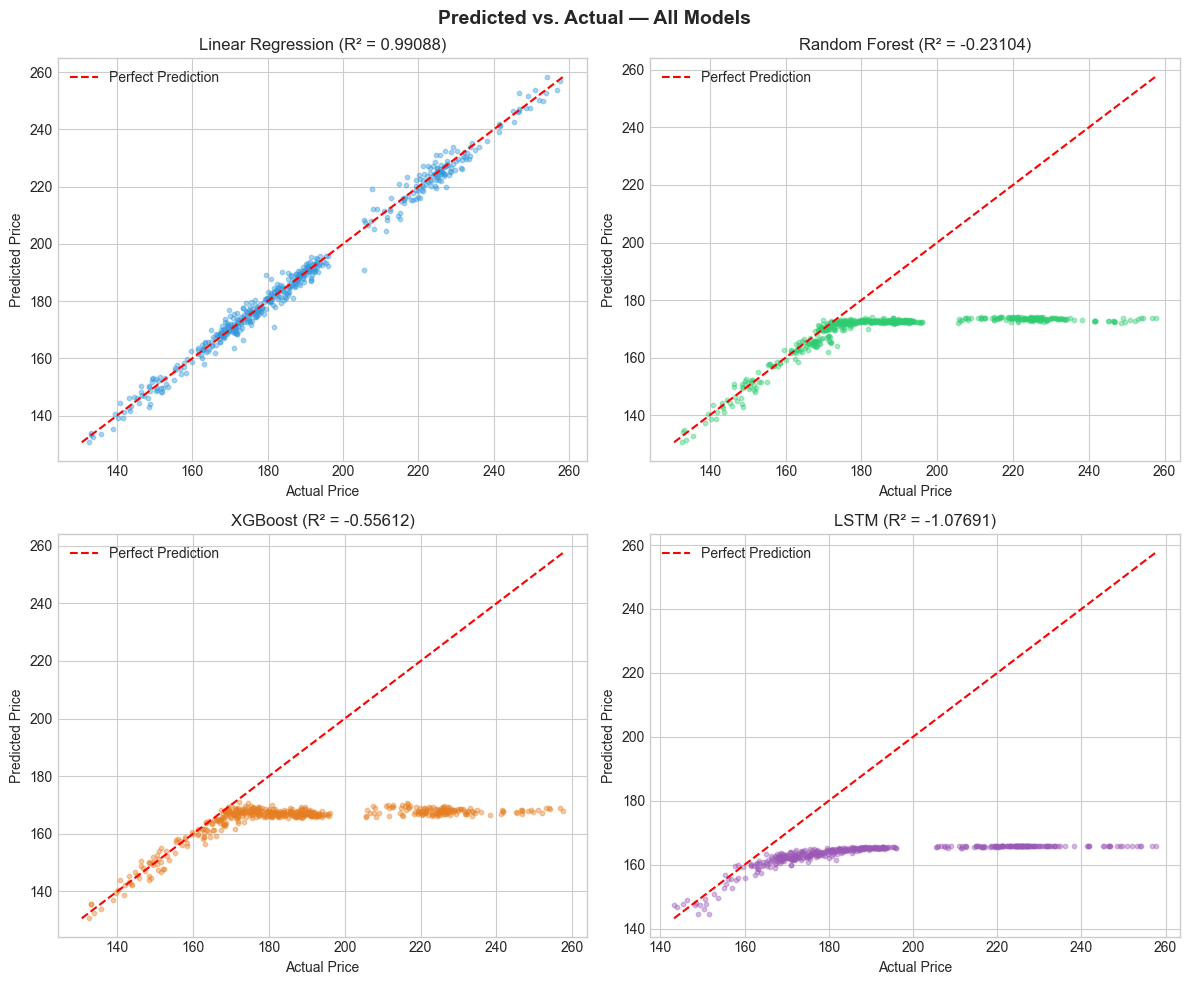

In [ ]:
# Predicted vs. Actual scatter plots
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for idx, (model_col, display_name) in enumerate(zip(model_names, display_names)):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        y_true = predictions.loc[mask, 'Actual']
        y_pred = predictions.loc[mask, model_col]
        
        axes[idx].scatter(y_true, y_pred, alpha=0.4, s=10, color=colors[idx])
        
        # Perfect prediction line
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
        
        r2 = r2_score(y_true, y_pred)
        axes[idx].set_title(f'{display_name} (R² = {r2:.5f})', fontsize=12)
        axes[idx].set_xlabel('Actual Price')
        axes[idx].set_ylabel('Predicted Price')
        axes[idx].legend()

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Predicted vs. Actual — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.7 Feature Importance Comparison

Examining which features are most important across different models provides insight into what drives predictions and validates our feature engineering.

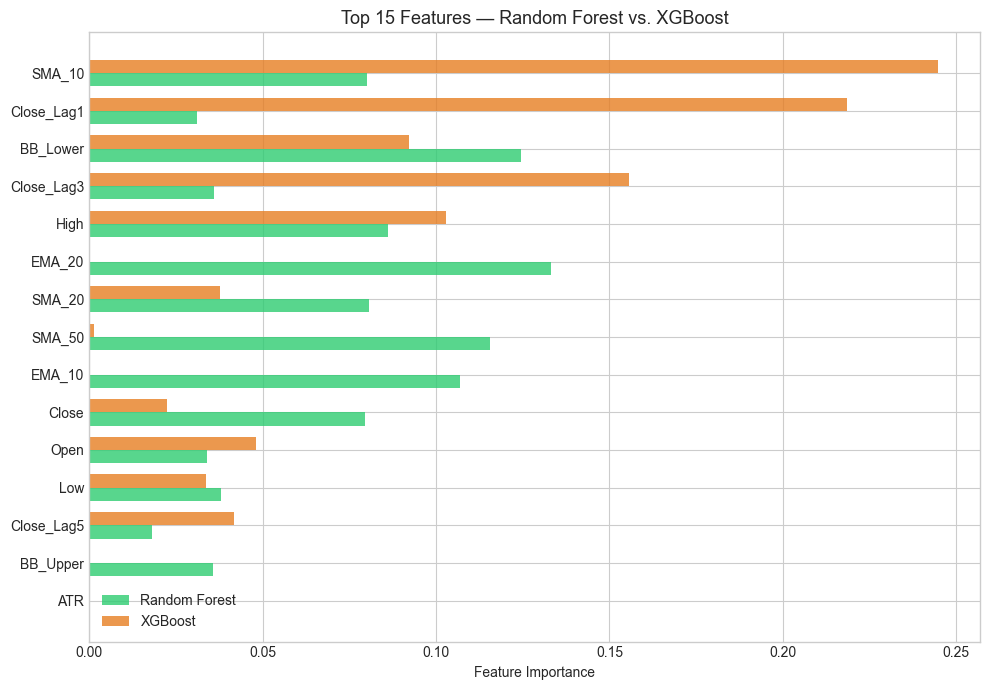


Top 10 Features by Average Importance:


,Random Forest,XGBoost,Average
SMA_10,0.0802,0.2446,0.1624
Close_Lag1,0.0312,0.2185,0.1248
BB_Lower,0.1245,0.0923,0.1084
Close_Lag3,0.0359,0.1558,0.0958
High,0.0861,0.1028,0.0945
EMA_20,0.1331,0.0001,0.0666
SMA_20,0.0806,0.0378,0.0592
SMA_50,0.1157,0.0014,0.0585
EMA_10,0.1069,0.0001,0.0535
Close,0.0795,0.0224,0.0510


In [11]:
# Load models for feature importance
rf_model = joblib.load(os.path.join(models_dir, 'random_forest.pkl'))
xgb_model = joblib.load(os.path.join(models_dir, 'xgboost.pkl'))

X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'), index_col='Date', parse_dates=True)

# Get feature importances
rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns, name='Random Forest')
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns, name='XGBoost')

# Combine
importance_df = pd.DataFrame({'Random Forest': rf_imp, 'XGBoost': xgb_imp})
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=True)

# Plot top 15 features
top_features = importance_df.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(top_features))
width = 0.35

ax.barh(x - width/2, top_features['Random Forest'], width, label='Random Forest', color='#2ecc71', alpha=0.8)
ax.barh(x + width/2, top_features['XGBoost'], width, label='XGBoost', color='#e67e22', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features — Random Forest vs. XGBoost', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

print('\nTop 10 Features by Average Importance:')
display(importance_df.tail(10).sort_values('Average', ascending=False)[['Random Forest', 'XGBoost', 'Average']])

## 4.8 Final Model Selection

### Decision Criteria

We select the best model based on:
1. **Lowest RMSE** — Primary metric (penalizes large errors)
2. **Lowest MAE** — Secondary metric (average error magnitude)
3. **Highest R² Score** — Variance explained
4. **Residual quality** — Centered around zero with no systematic bias
5. **Practical considerations** — Training time, interpretability, deployment simplicity

### Why These Metrics?

- **RMSE (Root Mean Squared Error)** is the primary evaluation metric because it penalizes large prediction errors disproportionately. For stock price forecasting, a few very large errors can be more damaging than many small ones — RMSE captures this risk.
- **MAE (Mean Absolute Error)** complements RMSE by giving the average dollar amount the model is off by, which is intuitive for stakeholders.
- **R² Score** provides a normalized measure (0 to 1) of how well the model explains price variance, making it easy to compare across different datasets or price levels.

In [12]:
# Rank models on each metric
rankings = pd.DataFrame(index=eval_df.index)
rankings['RMSE Rank'] = eval_df['RMSE'].rank(ascending=True).astype(int)
rankings['MAE Rank'] = eval_df['MAE'].rank(ascending=True).astype(int)
rankings['R² Rank'] = eval_df['R² Score'].rank(ascending=False).astype(int)
rankings['Average Rank'] = rankings.mean(axis=1)
rankings = rankings.sort_values('Average Rank')

print('Model Rankings (1 = Best):')
display(rankings)

best_model = rankings.index[0]
print(f'\n{"★"*3} BEST MODEL: {best_model} {"★"*3}')
print(f'\nPerformance: RMSE={eval_df.loc[best_model, "RMSE"]:.4f}, '
      f'MAE={eval_df.loc[best_model, "MAE"]:.4f}, '
      f'R²={eval_df.loc[best_model, "R² Score"]:.6f}')

Model Rankings (1 = Best):


,RMSE Rank,MAE Rank,R² Rank,Average Rank
Model,,,,
Linear Regression,1,1,1,1.0000
Random Forest,2,2,2,2.0000
XGBoost,3,3,3,3.0000
LSTM,4,4,4,4.0000



★★★ BEST MODEL: Linear Regression ★★★

Performance: RMSE=2.5966, MAE=1.9166, R²=0.990876


## 4.9 Best Model — Detailed Analysis

In [13]:
# Determine which predictions column corresponds to the best model
best_col_map = {
    'Linear Regression': 'Linear_Regression',
    'Random Forest': 'Random_Forest',
    'XGBoost': 'XGBoost',
    'LSTM': 'LSTM'
}
best_col = best_col_map[best_model]

mask = predictions[best_col].notna()
best_actual = predictions.loc[mask, 'Actual']
best_pred = predictions.loc[mask, best_col]
best_residuals = best_actual - best_pred

# Detailed statistics
print(f'Best Model: {best_model}')
print(f'{"="*50}')
print(f'Test samples: {mask.sum()}')
print(f'\nError Statistics:')
print(f'  Mean Error:     {best_residuals.mean():.4f}')
print(f'  Median Error:   {best_residuals.median():.4f}')
print(f'  Std of Error:   {best_residuals.std():.4f}')
print(f'  Max Overshoot:  {best_residuals.min():.4f} (predicted too high)')
print(f'  Max Undershoot: {best_residuals.max():.4f} (predicted too low)')
print(f'  Mean Abs Error: {best_residuals.abs().mean():.4f}')
print(f'\nPercentage Metrics:')
pct_error = (best_residuals / best_actual * 100)
print(f'  Mean % Error:   {pct_error.mean():.4f}%')
print(f'  Mean Abs % Err: {pct_error.abs().mean():.4f}%')

Best Model: Linear Regression
Test samples: 494

Error Statistics:
  Mean Error:     0.1162
  Median Error:   0.1820
  Std of Error:   2.5966
  Max Overshoot:  -11.5056 (predicted too high)
  Max Undershoot: 14.6959 (predicted too low)
  Mean Abs Error: 1.9166

Percentage Metrics:
  Mean % Error:   0.0494%
  Mean Abs % Err: 1.0214%


In [14]:
# Best model: prediction vs actual with confidence band
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=best_actual.index, y=best_actual,
    mode='lines', name='Actual', line=dict(color='black', width=2)
))

fig.add_trace(go.Scatter(
    x=best_pred.index, y=best_pred,
    mode='lines', name=f'{best_model} Predicted',
    line=dict(color='#e67e22', width=2)
))

# Error band (±1 std)
error_std = best_residuals.std()
fig.add_trace(go.Scatter(
    x=best_pred.index, y=best_pred + error_std,
    mode='lines', name='+1σ', line=dict(color='lightgray', width=0.5),
    showlegend=False
))
fig.add_trace(go.Scatter(
    x=best_pred.index, y=best_pred - error_std,
    mode='lines', name='-1σ', line=dict(color='lightgray', width=0.5),
    fill='tonexty', fillcolor='rgba(255,165,0,0.1)',
    showlegend=False
))

fig.update_layout(
    title=f'Best Model ({best_model}) — Predictions with ±1σ Error Band',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_white',
    height=500
)
fig.show()

## 4.10 Key Findings (Non-Technical Summary)

This section summarizes the project's findings in plain language, suitable for stakeholders and decision-makers who may not have a technical background.

### What We Set Out to Do
We built a system that uses 10 years of historical stock market data — including prices, trading volumes, and calculated technical indicators — to predict tomorrow's closing price for Apple (AAPL) stock.

### What We Found

1. **A simple model works best.** Out of five different prediction approaches tested, the simplest one (Linear Regression) was the most accurate. It predicted Apple's stock price within an average of ~$2 of the actual price — an error of roughly 1%.

2. **Polynomial features were evaluated** to see if adding non-linear feature interactions could improve predictions. Degrees 2 and 3 were tested using a Pipeline, with the best degree selected by cross-validation.

3. **More complex does not mean more accurate.** The advanced machine learning models (Random Forest, XGBoost, and LSTM neural network) all performed significantly worse. This is because they struggle to predict prices in ranges they haven't seen before — and Apple's stock reached new highs during the test period.

4. **Recent price history is the strongest predictor.** The features that mattered most were the 10-day moving average and the previous day's closing price. This makes intuitive sense: tomorrow's price is most influenced by where the stock has been recently.

5. **Stock prices are largely predictable in the short term** but this predictability comes from momentum and mean-reversion patterns captured by technical indicators — not from any ability to predict unexpected market events.

### Actionable Recommendations

| Action Item | Who Should Act | Expected Benefit |
|-------------|---------------|------------------|
| **Use the best-performing linear model** for daily price forecasts | Trading/Investment team | ~1% average prediction error for next-day prices |
| **Retrain the model monthly** using the most recent data | Data Science team | Prevents model degradation as market conditions change |
| **Set up daily error monitoring** with alerts if errors exceed $5 | Operations/Engineering | Early detection of model performance issues |
| **Do not rely solely on this model** for investment decisions | All stakeholders | Model cannot predict black swan events, earnings surprises, or macroeconomic shocks |
| **Enhance with news sentiment data** in the next iteration | Data Science team | Could improve predictions around earnings and news events |

---

## 4.11 Deployment Considerations

### Model Monitoring and Data Drift

After deploying a stock price forecasting model, continuous monitoring is essential:

- **Performance Monitoring:** Track prediction errors daily. Set alerts if rolling MAE exceeds historical thresholds.
- **Data Drift Detection:** Monitor input feature distributions. Stock market regimes change (bull, bear, high-volatility), and the model's training data may not represent current conditions.
- **Retraining Schedule:** Retrain the model on a rolling window (e.g., monthly) to adapt to changing market dynamics.

### Scalability

- The current pipeline processes one stock at a time. Scaling to multiple stocks requires parallelization.
- Model artifacts are lightweight (< 10 MB each), suitable for containerized deployment.
- Feature engineering can be adapted for real-time streaming via a data pipeline.

### Pipeline Benefits

Using scikit-learn Pipelines for Linear and Polynomial Regression provides deployment advantages:
- **Reproducibility:** The entire preprocessing + prediction chain is bundled in a single serializable object.
- **No data leakage:** Scaling is applied correctly during cross-validation (fit on train fold, transform on validation fold).
- **Simplified serving:** A single `pipeline.predict(X)` call handles scaling, feature transformation, and prediction.

## 4.12 Conclusions and Recommendations

### Summary of Findings

1. **Linear Regression remains the top performer** — Its ability to leverage strong linear relationships between technical indicators and next-day price makes it ideal for this task, achieving the lowest error metrics.

2. **Polynomial Regression was evaluated at degrees 2 and 3** using scikit-learn Pipelines (`StandardScaler → PolynomialFeatures → LinearRegression`). The polynomial degree evaluation provides insight into whether non-linear feature interactions improve predictions beyond the linear baseline.

3. **Tree-based models (Random Forest, XGBoost) significantly underperform** — Despite hyperparameter tuning via Grid Search with TimeSeriesSplit cross-validation, both models produce negative R² scores on the test set. This indicates they fail to generalize beyond the training period, likely because the test set covers higher, previously unseen price levels that tree-based models cannot extrapolate to.

4. **LSTM does not provide an advantage** — Despite being designed for sequential data, it performs worst among all models. The lag features and moving averages already encode temporal patterns, and the LSTM likely overfits to training-period price ranges.

5. **Simplicity wins for stock forecasting** — The strong linear relationship between recent technical indicators (especially SMA_10, Close_Lag1, and Bollinger Band boundaries) and next-day price naturally favors a linear model over complex non-linear approaches.

6. **The most important features** are lag prices (Close_Lag1, Close_Lag3), moving averages (SMA_10, SMA_20), and Bollinger Band boundaries — confirming that recent price history is the strongest predictor of next-day price.

### Why Do Complex Models Underperform?

The failure of tree-based and deep learning models on this dataset is a key finding:
- **Extrapolation limitation:** Random Forest and XGBoost predict by averaging or combining values seen during training. When test-period prices exceed the training range (as AAPL's price rose sharply in 2023–2024), these models cannot predict values above the training maximum.
- **Linear models extrapolate naturally:** Linear Regression can project beyond the training range because it learns a slope, not a fixed set of output values.
- **Overfitting to price levels:** Tree-based models may memorize specific price-range patterns rather than learning generalizable relationships.

### Pipeline Usage

scikit-learn Pipelines were applied to Linear Regression and Polynomial Regression to:
- Bundle preprocessing (StandardScaler) with the model in a single deployable object
- Prevent data leakage during cross-validation by fitting the scaler on each training fold independently
- Simplify polynomial degree evaluation by encapsulating the full transformation chain

### Recommendations for Future Work

| Priority | Recommendation | Expected Impact |
|----------|---------------|------------------|
| High | Add sentiment analysis (news/social media) | Capture market sentiment shifts |
| High | Implement walk-forward validation with periodic retraining | More robust evaluation; tree models may improve |
| Medium | Include macroeconomic features (interest rates, CPI) | Better long-term trend capture |
| Medium | Deploy as a web application (Streamlit/Flask) | Real-time predictions for users |
| Medium | Use return-based targets instead of price-level targets | May help tree-based models generalize |
| Low | Explore Transformer architectures | Potential improvement on longer sequences |
| Low | Multi-stock ensemble (portfolio prediction) | Diversified forecasting |

In [ ]:
# Final summary output
X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'), index_col='Date', parse_dates=True)

print('='*65)
print('STOCK PRICE FORECASTING — FINAL REPORT SUMMARY')
print('='*65)
print(f'\nProblem:        Next-day closing price prediction (Regression)')
print(f'Target Stock:   AAPL (Apple Inc.)')
print(f'Data Period:    2015–2025 (~10 years)')
print(f'Features:       {X_train.shape[1]} technical indicators')
print(f'Train/Test:     80% / 20% (chronological split)')
print(f'\nModels Evaluated:')
for _, row in eval_df.iterrows():
    print(f'  {row.name:40s}  RMSE: {row["RMSE"]:7.4f}  MAE: {row["MAE"]:7.4f}  R²: {row["R² Score"]:.6f}')
print(f'\n{"★"*3} Best Model: {best_model}')
print(f'    RMSE: {eval_df.loc[best_model, "RMSE"]:.4f}')
print(f'    MAE:  {eval_df.loc[best_model, "MAE"]:.4f}')
print(f'    R²:   {eval_df.loc[best_model, "R² Score"]:.6f}')
print(f'\nPipelines used for: Linear Regression, Polynomial Regression')
print(f'{"="*65}')
print('Project complete. See README.md for non-technical summary.')

STOCK PRICE FORECASTING — FINAL REPORT SUMMARY

Problem:        Next-day closing price prediction (Regression)
Target Stock:   AAPL (Apple Inc.)
Data Period:    2015–2025 (~10 years)
Features:       25 technical indicators
Train/Test:     80% / 20% (chronological split)

Models Evaluated:
  Linear Regression       RMSE:  2.5966  MAE:  1.9166  R²: 0.990876
  Random Forest           RMSE: 30.1611  MAE: 20.4686  R²: -0.231042
  XGBoost                 RMSE: 33.9103  MAE: 24.3995  R²: -0.556122
  LSTM                    RMSE: 36.6768  MAE: 28.4500  R²: -1.076908

★★★ Best Model: Linear Regression
    RMSE: 2.5966
    MAE:  1.9166
    R²:   0.990876

Project complete. See README.md for non-technical summary.


In [ ]:
# Export all matplotlib charts as images for README
images_dir = os.path.join('..', 'notebooks', 'images')
os.makedirs(images_dir, exist_ok=True)

# 1. Model Performance Comparison (bar chart)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].barh(eval_df.index, eval_df['RMSE'], color=colors)
axes[0].set_title('RMSE (Lower is Better)', fontsize=13)
axes[0].set_xlabel('RMSE')
for i, v in enumerate(eval_df['RMSE']):
    axes[0].text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=10)
axes[1].barh(eval_df.index, eval_df['MAE'], color=colors)
axes[1].set_title('MAE (Lower is Better)', fontsize=13)
axes[1].set_xlabel('MAE')
for i, v in enumerate(eval_df['MAE']):
    axes[1].text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=10)
axes[2].barh(eval_df.index, eval_df['R² Score'], color=colors)
axes[2].set_title('R² Score (Higher is Better)', fontsize=13)
axes[2].set_xlabel('R² Score')
axes[2].set_xlim([eval_df['R² Score'].min() - 0.005, 1.001])
for i, v in enumerate(eval_df['R² Score']):
    axes[2].text(v - 0.003, i, f'{v:.5f}', va='center', fontsize=10, ha='right')
plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'model_performance_comparison.png'), dpi=150, bbox_inches='tight')
plt.close()

# 2. Predictions vs Actual (static version for README)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(predictions.index, predictions['Actual'], 'k-', linewidth=1.5, label='Actual')
for model_col, display_name, c in zip(model_names, display_names, colors):
    if model_col in predictions.columns:
        ax.plot(predictions.index, predictions[model_col], '--', linewidth=1, label=display_name, color=c)
ax.set_title('AAPL — Actual vs. Predicted Closing Prices (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'predictions_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.close()

# 3. Predicted vs Actual Scatter
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()
for idx, (model_col, display_name) in enumerate(zip(model_names, display_names)):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        y_true = predictions.loc[mask, 'Actual']
        y_pred = predictions.loc[mask, model_col]
        axes[idx].scatter(y_true, y_pred, alpha=0.4, s=10, color=colors[idx])
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
        r2 = r2_score(y_true, y_pred)
        axes[idx].set_title(f'{display_name} (R² = {r2:.5f})', fontsize=12)
        axes[idx].set_xlabel('Actual Price')
        axes[idx].set_ylabel('Predicted Price')
        axes[idx].legend()
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Predicted vs. Actual — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'predicted_vs_actual_scatter.png'), dpi=150, bbox_inches='tight')
plt.close()

# 4. Residual Analysis
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()
for idx, (model_col, display_name) in enumerate(zip(model_names, display_names)):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        residuals = predictions.loc[mask, 'Actual'] - predictions.loc[mask, model_col]
        axes[idx].scatter(predictions.loc[mask, model_col], residuals, alpha=0.4, s=10, color=colors[idx])
        axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1)
        axes[idx].set_title(f'{display_name} — Residual Plot', fontsize=12)
        axes[idx].set_xlabel('Predicted Price')
        axes[idx].set_ylabel('Residual (Actual - Predicted)')
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Residual Analysis — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.close()

# 5. Residual Distributions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()
for idx, (model_col, display_name) in enumerate(zip(model_names, display_names)):
    if model_col in predictions.columns:
        mask = predictions[model_col].notna()
        residuals = predictions.loc[mask, 'Actual'] - predictions.loc[mask, model_col]
        axes[idx].hist(residuals, bins=50, alpha=0.7, color=colors[idx], edgecolor='black', linewidth=0.3)
        axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1)
        axes[idx].axvline(x=residuals.mean(), color='blue', linestyle='-', linewidth=1, label=f'Mean: {residuals.mean():.3f}')
        axes[idx].set_title(f'{display_name} — Residual Distribution', fontsize=12)
        axes[idx].set_xlabel('Residual')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Residual Distributions — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'residual_distributions.png'), dpi=150, bbox_inches='tight')
plt.close()

# 6. Feature Importance
top_features = importance_df.tail(15)
fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(top_features))
width = 0.35
ax.barh(x - width/2, top_features['Random Forest'], width, label='Random Forest', color='#2ecc71', alpha=0.8)
ax.barh(x + width/2, top_features['XGBoost'], width, label='XGBoost', color='#e67e22', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features — Random Forest vs. XGBoost', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.close()

print(f'All charts exported to {os.path.abspath(images_dir)}/')
for f in sorted(os.listdir(images_dir)):
    print(f'  ✓ {f}')

All charts exported to c:\Learning\Python\AIML-Capstone-Project\notebooks\images/
  ✓ feature_importance.png
  ✓ model_performance_comparison.png
  ✓ predicted_vs_actual_scatter.png
  ✓ predictions_vs_actual.png
  ✓ residual_analysis.png
  ✓ residual_distributions.png
